# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [1]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_genes = pd.read_csv('df_exerc7.csv', index_col=0, header=0)
df_genes.head()

,numero_caracteres,primeiras_letras,letras_a,presenca_hu
interleucina_6,14,in,1,False
interferon_gama,15,in,2,False
TNF-alpha,9,TN,2,False
interleucina_12,15,in,1,False
TGF-beta,8,TG,1,False


In [4]:
df_genes['id_entrez'] = [
    "NM_000600.5",
    "NM_000619.3",
    "NM_000594.4",
    "NM_001397992.1",
    "NM_000660.7",
]

df_genes['id_protein'] = [
    'NP_000591.1',
    "NP_000610.2",
    "NP_000585.2",
    "NP_001384921.1",
    "NP_000651.3",
]
df_genes

,numero_caracteres,primeiras_letras,letras_a,presenca_hu,id_entrez,id_protein
interleucina_6,14,in,1,False,NM_000600.5,NP_000591.1
interferon_gama,15,in,2,False,NM_000619.3,NP_000610.2
TNF-alpha,9,TN,2,False,NM_000594.4,NP_000585.2
interleucina_12,15,in,1,False,NM_001397992.1,NP_001384921.1
TGF-beta,8,TG,1,False,NM_000660.7,NP_000651.3


In [9]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "lizacharow@gmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [10]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

interleucina_6 NP_000591.1
interferon_gama NP_000610.2
TNF-alpha NP_000585.2
interleucina_12 NP_001384921.1
TGF-beta NP_000651.3


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [2]:
import os

dados = []
pasta = "data"

for arquivo in os.listdir(pasta):
    if arquivo.endswith(".fasta"):
        caminho = os.path.join(pasta, arquivo)
        with open(caminho, "r") as f:
            linhas = f.readlines()
        sequencia = ""
        for linha in linhas:
            if not linha.startswith(">"):
                sequencia += linha.strip()
        contagem = {}
        for amino in sequencia:
            if amino in contagem:
                contagem[amino] += 1
            else:
                contagem[amino] = 1
        contagem["gene"] = arquivo.replace(".fasta", "")
        dados.append(contagem)
df_amino = pd.DataFrame(dados).fillna(0)

df_amino

,M,K,Y,T,S,I,L,A,F,Q,...,V,G,D,P,E,N,H,W,R,gene
0,5,21,7,6,13,9,14,9,11,10,...,9,7,10,2,9,10,2,1.0,8,interferon_gama
1,11,13,5,15,19,10,33,15,9,8,...,10,2,11,10,14,11,5,0.0,10,interleucina_12
2,6,14,3,13,19,9,28,18,11,14,...,8,7,8,11,16,11,2,1.0,9,interleucina_6
3,7,18,16,17,31,14,52,24,10,14,...,23,20,14,30,26,15,10,7.0,30,TGF-beta
4,2,8,7,10,20,12,30,19,10,13,...,16,17,7,15,16,7,4,2.0,14,TNF-alpha


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [3]:
valinas = df_amino[["gene", "V"]]
valinas

,gene,V
0,interferon_gama,9
1,interleucina_12,10
2,interleucina_6,8
3,TGF-beta,23
4,TNF-alpha,16


In [4]:
max_gene_valinas = valinas.loc[valinas["V"].idxmax()]
max_gene_valinas

gene    TGF-beta
V             23
Name: 3, dtype: object

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [4]:
serinas = df_amino["S"]

media = serinas.mean()
mediana = serinas.median()
moda = serinas.mode()

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Média: 20.4
Mediana: 19.0
Moda: 0    19
Name: S, dtype: int64


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

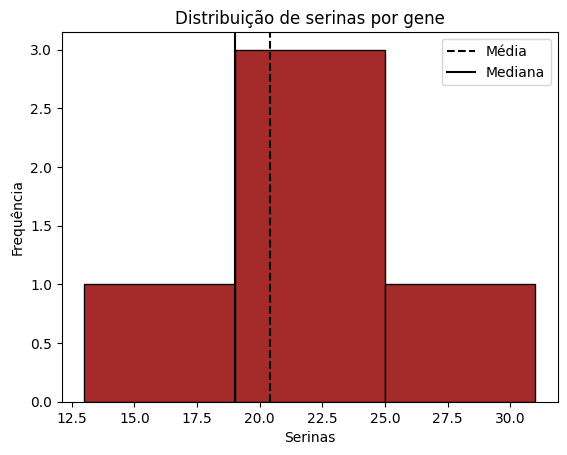

In [8]:
plt.hist(serinas, bins=3, color="brown", edgecolor="black")
plt.axvline(media, linestyle= '--', label= "Média", color="black")
plt.axvline(mediana, linestyle= '-', label= "Mediana", color="black")
plt.title("Distribuição de serinas por gene")
plt.xlabel("Serinas")
plt.ylabel("Frequência")
plt.legend(loc='upper right')
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [12]:
def analise_aa(df, aa):
    valores = df[aa]
    media = valores.mean()
    mediana = valores.median()
    plt.hist(valores, bins=3, color="brown", edgecolor="black")
    plt.axvline(media, linestyle= '--', label= "Média", color="black")
    plt.axvline(mediana, linestyle= '-', label= "Mediana", color="black")
    plt.title(f"Distribuição de {aa} por gene")
    plt.xlabel(f"{aa}")
    plt.ylabel("Frequência")
    plt.legend(loc='upper right')
    plt.show()
    return media, mediana

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

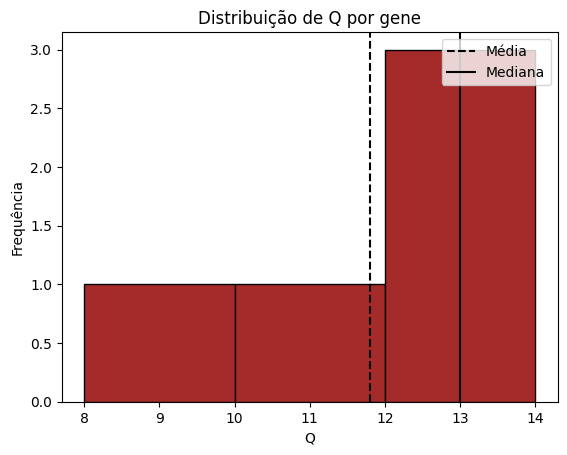

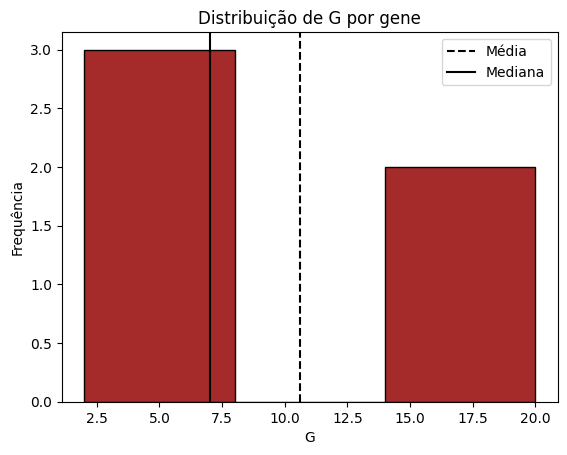

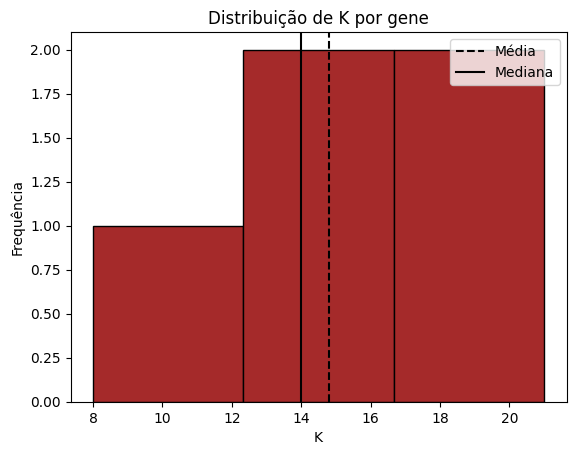

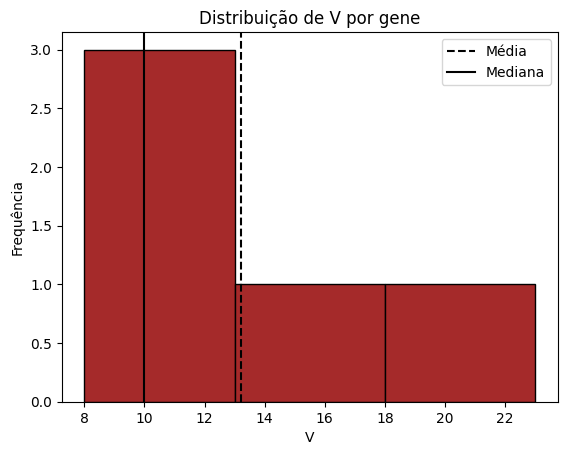

Diferenças: {'Q': np.float64(1.1999999999999993), 'G': np.float64(3.5999999999999996), 'K': np.float64(0.8000000000000007), 'V': np.float64(3.1999999999999993)}
Menor diferença: K


In [13]:
aminoacidos = ["Q", "G", "K", "V"]
resultados = {}
for aa in aminoacidos:
    media, mediana = analise_aa(df_amino, aa)
    diff = abs(media - mediana)
    resultados[aa] = diff

menor = min(resultados, key=resultados.get)

print("Diferenças:", resultados)
print("Menor diferença:", menor)

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [14]:
df_ex8 = df_amino.head(3)
cisteina = df_ex8["C"]
media_c = cisteina.mean()
mediana_c = cisteina.median()

print("Média:", media_c)
print("Mediana:", mediana_c)

Média: 5.0
Mediana: 4.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [3]:
df_amino["media_gene"] = df_amino.drop(columns=["gene"]).mean(axis=1)

maior_gene = df_amino.loc[df_amino["media_gene"].idxmax()]

print(maior_gene[["gene", "media_gene"]])

gene          TGF-beta
media_gene        19.5
Name: 3, dtype: object


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [4]:
menor_gene = df_amino.loc[df_amino["media_gene"].idxmin()]

print(menor_gene[["gene", "media_gene"]])

gene          interferon_gama
media_gene                8.3
Name: 0, dtype: object
